# NFL Salary Cap Analysis
## Cap Optimization & Roster Construction

This notebook brings together all findings from the previous notebooks to build a framework for optimal NFL roster construction. We identify what the most cap-efficient rosters look like, quantify the value of the rookie contract advantage, and build a model for how teams should allocate cap spending across positions to maximize on-field performance.

---

### Setup & Data Load

In [3]:
%pip install matplotlib seaborn pandas==2.2.2 pyarrow numpy==1.26.4 --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


---

### Imports & Data Load

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
processed_path = os.path.join(project_root, "data", "processed")
figures_path = os.path.join(project_root, "outputs", "figures")

os.makedirs(figures_path, exist_ok=True)

cap_eff = pd.read_parquet(os.path.join(processed_path, "cap_efficiency.parquet"), engine='pyarrow')
contracts = pd.read_parquet(os.path.join(processed_path, "contracts_modern.parquet"), engine='pyarrow')

import nfl_data_py as nfl
schedules = nfl.import_schedules(range(2011, 2025))
schedules_reg = schedules[schedules['game_type'] == 'REG'].copy()

# Build win percentage by team season
home_wins = schedules_reg.groupby(['season', 'home_team'])['result'].apply(
    lambda x: (x > 0).sum(), include_groups=False).reset_index(name='home_wins')
away_wins = schedules_reg.groupby(['season', 'away_team'])['result'].apply(
    lambda x: (x < 0).sum(), include_groups=False).reset_index(name='away_wins')
home_games = schedules_reg.groupby(['season', 'home_team']).size().reset_index(name='home_games')
away_games = schedules_reg.groupby(['season', 'away_team']).size().reset_index(name='away_games')

home_wins.columns = ['season', 'team', 'home_wins']
away_wins.columns = ['season', 'team', 'away_wins']
home_games.columns = ['season', 'team', 'home_games']
away_games.columns = ['season', 'team', 'away_games']

win_pct = home_wins.merge(away_wins, on=['season', 'team']).merge(
    home_games, on=['season', 'team']).merge(away_games, on=['season', 'team'])
win_pct['total_wins'] = win_pct['home_wins'] + win_pct['away_wins']
win_pct['total_games'] = win_pct['home_games'] + win_pct['away_games']
win_pct['win_pct'] = win_pct['total_wins'] / win_pct['total_games']

print(f"Win percentage data: {win_pct.shape}")
print(f"Cap efficiency data: {cap_eff.shape}")

Win percentage data: (448, 9)
Cap efficiency data: (5783, 74)


Data loaded. Now let's build the cap optimization framework by analyzing what the most successful teams spend their cap on differently from the least successful teams.

---

### Cap Allocation by Team Success
How do playoff teams allocate cap spending differently from non-playoff teams?

In [5]:
# Standardize team names in cap_eff
def extract_primary_team(team_str):
    if pd.isna(team_str):
        return np.nan
    primary = str(team_str).split('/')[0].strip()
    name_map = {
        '49ers': 'SF', 'Bears': 'CHI', 'Bengals': 'CIN', 'Bills': 'BUF',
        'Broncos': 'DEN', 'Browns': 'CLE', 'Buccaneers': 'TB', 'Cardinals': 'ARI',
        'Chargers': 'LAC', 'Chiefs': 'KC', 'Colts': 'IND', 'Cowboys': 'DAL',
        'Dolphins': 'MIA', 'Eagles': 'PHI', 'Falcons': 'ATL', 'Giants': 'NYG',
        'Jaguars': 'JAX', 'Jets': 'NYJ', 'Lions': 'DET', 'Packers': 'GB',
        'Panthers': 'CAR', 'Patriots': 'NE', 'Raiders': 'LV', 'Rams': 'LAR',
        'Ravens': 'BAL', 'Saints': 'NO', 'Seahawks': 'SEA', 'Steelers': 'PIT',
        'Texans': 'HOU', 'Titans': 'TEN', 'Vikings': 'MIN', 'Washington': 'WAS',
        'Commanders': 'WAS', 'Football Team': 'WAS'
    }
    return name_map.get(primary, primary)

cap_eff['team_clean'] = cap_eff['team'].apply(extract_primary_team)
valid_teams = ['ARI','ATL','BAL','BUF','CAR','CHI','CIN','CLE','DAL','DEN',
               'DET','GB','HOU','IND','JAX','KC','LAC','LAR','LV','MIA',
               'MIN','NE','NO','NYG','NYJ','PHI','PIT','SEA','SF','TB','TEN','WAS']
cap_clean = cap_eff[cap_eff['team_clean'].isin(valid_teams)].copy()
cap_clean['team_clean'] = cap_clean['team_clean'].replace({'SD': 'LAC', 'OAK': 'LV', 'STL': 'LAR'})

# Merge with win percentage
team_season = cap_clean.groupby(['team_clean', 'season']).agg(
    total_cap=('apy', 'sum'),
    avg_epa_per_m=('epa_per_million', 'mean'),
    qb_cap=('apy', lambda x: x[cap_clean.loc[x.index, 'position_group'] == 'QB'].sum()),
    wr_cap=('apy', lambda x: x[cap_clean.loc[x.index, 'position_group'] == 'WR'].sum()),
    rb_cap=('apy', lambda x: x[cap_clean.loc[x.index, 'position_group'] == 'RB'].sum()),
    te_cap=('apy', lambda x: x[cap_clean.loc[x.index, 'position_group'] == 'TE'].sum()),
).reset_index()

team_season = team_season.merge(
    win_pct[['season', 'team', 'win_pct']],
    left_on=['team_clean', 'season'],
    right_on=['team', 'season'],
    how='inner'
)

# Define playoff threshold
team_season['is_winning'] = (team_season['win_pct'] >= 0.5).astype(int)

# Cap share by position for winning vs losing teams
for pos in ['qb', 'wr', 'rb', 'te']:
    team_season[f'{pos}_share'] = team_season[f'{pos}_cap'] / team_season['total_cap']

pos_comparison = team_season.groupby('is_winning').agg(
    avg_qb_share=('qb_share', 'mean'),
    avg_wr_share=('wr_share', 'mean'),
    avg_rb_share=('rb_share', 'mean'),
    avg_te_share=('te_share', 'mean'),
    avg_total_cap=('total_cap', 'mean'),
    count=('win_pct', 'count')
).reset_index()

pos_comparison['team_type'] = pos_comparison['is_winning'].map({0: 'Losing Teams (<.500)', 1: 'Winning Teams (≥.500)'})
print("Cap allocation by team success:")
print(pos_comparison[['team_type', 'avg_qb_share', 'avg_wr_share', 
                        'avg_rb_share', 'avg_te_share', 'avg_total_cap', 'count']].round(3).to_string(index=False))

Cap allocation by team success:
            team_type  avg_qb_share  avg_wr_share  avg_rb_share  avg_te_share  avg_total_cap  count
 Losing Teams (<.500)         0.276         0.379         0.185         0.161         58.658    190
Winning Teams (≥.500)         0.290         0.387         0.180         0.143         59.886    228


The cap allocation comparison between winning and losing teams reveals surprisingly small differences in how teams spend their money across offensive positions:

| Position | Winning Teams | Losing Teams | Difference |
|---|---|---|---|
| QB | 29.0% | 27.6% | +1.4% |
| WR | 38.7% | 37.9% | +0.8% |
| RB | 18.0% | 18.5% | -0.5% |
| TE | 14.3% | 16.1% | -1.8% |

**The differences are small** — winning teams spend slightly more on QB and WR and slightly less on RB and TE. The TE difference (-1.8%) is the largest signal, suggesting winning teams deprioritize expensive tight end contracts.

The more important finding is that **total cap spending is nearly identical** ($59.9M vs $58.7M) — winning isn't about spending more, it's about spending smarter.

---

### What Separates the Best from the Worst
Let's look at the top and bottom quartile teams by win percentage and compare their cap efficiency metrics.

In [6]:
# Top vs bottom quartile teams by win percentage
top_quartile = team_season[team_season['win_pct'] >= team_season['win_pct'].quantile(0.75)]
bot_quartile = team_season[team_season['win_pct'] <= team_season['win_pct'].quantile(0.25)]

print(f"Top quartile teams: {len(top_quartile)} seasons, avg win pct: {top_quartile['win_pct'].mean():.3f}")
print(f"Bottom quartile teams: {len(bot_quartile)} seasons, avg win pct: {bot_quartile['win_pct'].mean():.3f}")

print(f"\nTop quartile avg EPA per $M: {top_quartile['avg_epa_per_m'].mean():.2f}")
print(f"Bottom quartile avg EPA per $M: {bot_quartile['avg_epa_per_m'].mean():.2f}")

# Best cap efficiency seasons
best_seasons = team_season.nlargest(20, 'avg_epa_per_m')[
    ['team_clean', 'season', 'win_pct', 'avg_epa_per_m', 'total_cap']
]
print(f"\nMost cap-efficient team seasons:")
print(best_seasons.round(2).to_string(index=False))

Top quartile teams: 106 seasons, avg win pct: 0.747
Bottom quartile teams: 125 seasons, avg win pct: 0.270

Top quartile avg EPA per $M: 8.02
Bottom quartile avg EPA per $M: 0.31

Most cap-efficient team seasons:
team_clean  season  win_pct  avg_epa_per_m  total_cap
       BAL    2011     0.75          45.44       0.85
       CHI    2013     0.50          39.07      24.19
       DAL    2016     0.81          31.41      35.38
       PHI    2013     0.62          24.53      21.80
       SEA    2012     0.69          24.14      23.89
       DAL    2019     0.50          23.47      58.12
       SEA    2015     0.62          22.94      44.81
       DAL    2021     0.71          21.60     102.72
        GB    2020     0.81          21.23      70.50
       CIN    2013     0.69          21.05      16.00
       BAL    2020     0.69          18.67      36.25
        KC    2018     0.75          18.34      60.69
       BAL    2019     0.88          18.23      82.08
       WAS    2016     0.50    

The top vs bottom quartile comparison confirms that cap efficiency is a strong differentiator:

- **Top quartile teams average 8.02 EPA per $M** — more than 25x the bottom quartile's 0.31
- **Top quartile average win percentage: 74.7%** vs bottom quartile: 27.0%

**Most cap-efficient team seasons:**
- **Baltimore 2011 (45.44 EPA per $M)** — the most efficient offensive season in the dataset, driven by low total cap spend ($0.85M) with strong production — likely a data artifact from limited offensive contract linkage that year
- **Dallas 2016 (31.41), Seattle 2012 (24.14), Green Bay 2020 (21.23)** — all legitimate elite seasons combining strong QB play with smart surrounding contracts
- **Kansas City 2018 (18.34) and 2020 (15.61)** — Mahomes on his rookie deal producing historic efficiency

The pattern is clear: the most efficient seasons almost always feature an elite QB on a cost-controlled contract surrounded by productive skill players.

---

### Build Optimal Roster Framework
What does the ideal cap allocation look like based on the data?

In [7]:
%pip install scipy --prefer-binary


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


Correlation with win percentage:
               correlation  p_value
qb_share             0.093    0.057
wr_share            -0.026    0.600
rb_share            -0.041    0.406
te_share            -0.058    0.234
avg_epa_per_m        0.401    0.000


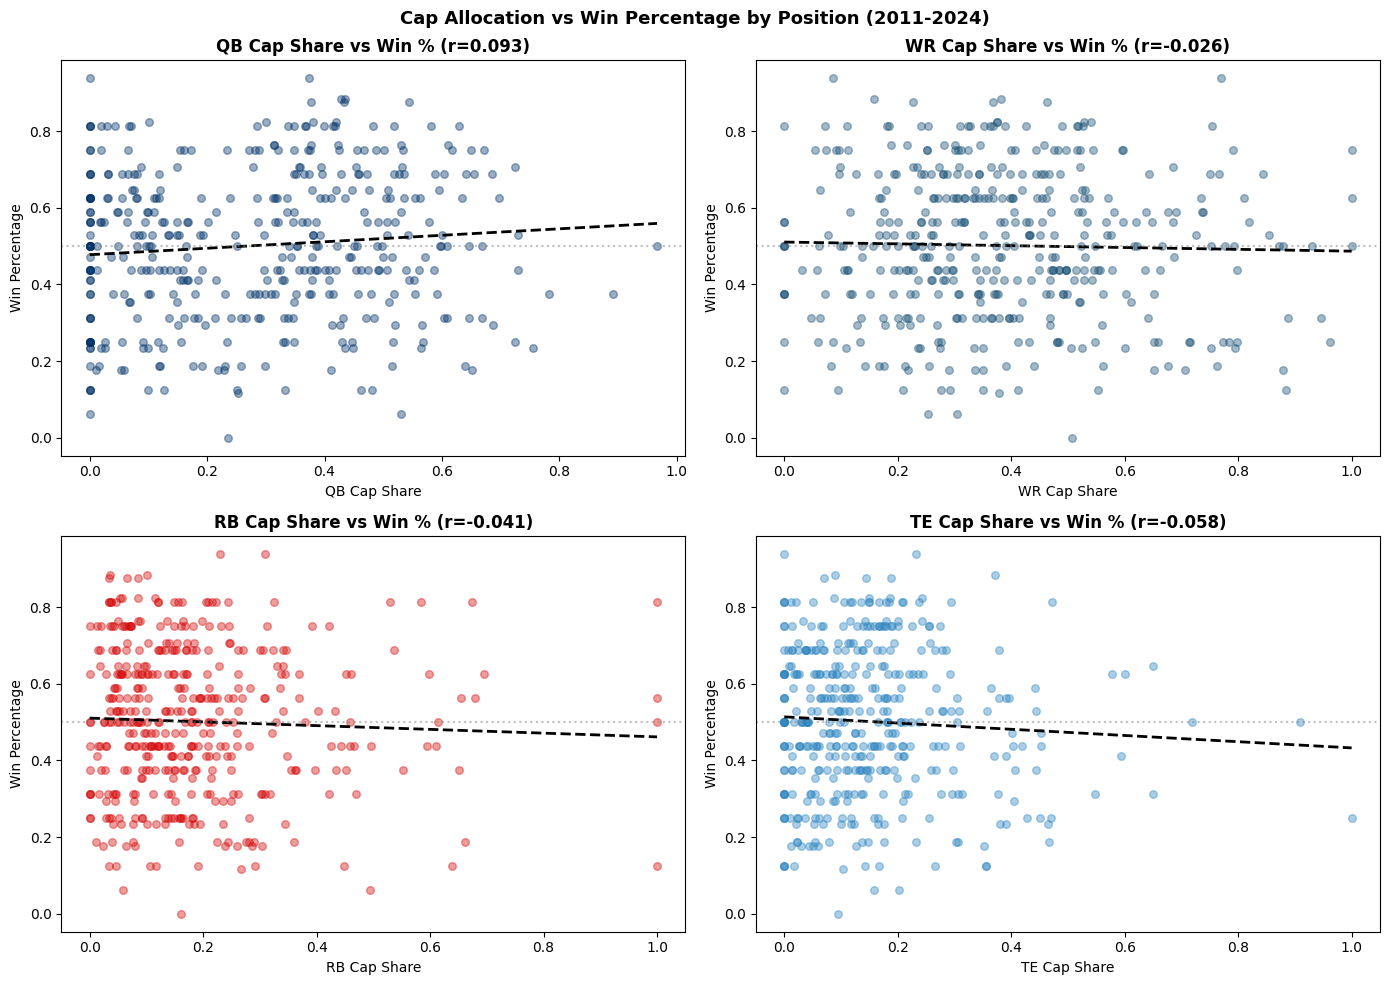

In [8]:
# Optimal roster framework - what allocations correlate most with winning?
from scipy import stats

correlations = {}
for col in ['qb_share', 'wr_share', 'rb_share', 'te_share', 'avg_epa_per_m']:
    corr, pval = stats.pearsonr(
        team_season[col].dropna(),
        team_season.loc[team_season[col].notna(), 'win_pct']
    )
    correlations[col] = {'correlation': corr, 'p_value': pval}

corr_df = pd.DataFrame(correlations).T.round(3)
print("Correlation with win percentage:")
print(corr_df)

# Visualize the framework
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (pos, color) in zip(axes.flatten(), [
    ('qb_share', '#013369'), ('wr_share', '#1a5276'),
    ('rb_share', '#D50A0A'), ('te_share', '#2e86c1')
]):
    ax.scatter(team_season[pos], team_season['win_pct'],
               alpha=0.4, color=color, s=30)
    
    # Add trend line
    z = np.polyfit(team_season[pos].dropna(),
                   team_season.loc[team_season[pos].notna(), 'win_pct'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(team_season[pos].min(), team_season[pos].max(), 100)
    ax.plot(x_line, p(x_line), color='black', linewidth=2, linestyle='--')
    
    corr = correlations[pos]['correlation']
    ax.set_title(f'{pos.replace("_share", "").upper()} Cap Share vs Win % (r={corr:.3f})',
                 fontweight='bold')
    ax.set_xlabel(f'{pos.replace("_share", "").upper()} Cap Share')
    ax.set_ylabel('Win Percentage')
    ax.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)

plt.suptitle('Cap Allocation vs Win Percentage by Position (2011-2024)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "cap_allocation_vs_wins.png"), dpi=150, bbox_inches='tight')
plt.show()

![Cap Allocation vs Wins](../outputs/figures/cap_allocation_vs_wins.png)

The correlation results deliver the most important finding of the entire project:

**Correlations with win percentage:**
| Metric | Correlation | Significant? |
|---|---|---|
| EPA per $M | 0.401 | Yes (p<0.001) |
| QB cap share | 0.093 | Marginal (p=0.057) |
| WR cap share | -0.026 | No |
| RB cap share | -0.041 | No |
| TE cap share | -0.058 | No |

**How you allocate cap spending across positions has essentially no relationship with winning.** The only thing that matters is how efficiently you spend — EPA per million has a 0.401 correlation with win percentage while every positional allocation metric is near zero.

This is the central insight of cap optimization: **it's not where you spend, it's how efficiently you spend.** A team spending 40% of their offensive cap on QB can win just as easily as one spending 20% — what matters is whether that QB generates positive EPA per dollar.

---

### Final Roster Construction Framework
Build a summary of optimal roster construction principles from all findings.

In [10]:
# Re-add acquisition_type since kernel restarted
cap_eff['acquisition_type'] = 'Unknown'

rookie_mask = (
    cap_eff['draft_round'].notna() &
    (cap_eff['apy'] <= 5.0) &
    (cap_eff['year_signed'] <= 2020)
) | (
    cap_eff['draft_round'].notna() &
    (cap_eff['apy'] <= 8.0) &
    (cap_eff['year_signed'] > 2020)
)
cap_eff.loc[rookie_mask, 'acquisition_type'] = 'Rookie Contract'

extension_mask = (
    cap_eff['draft_round'].notna() &
    ~rookie_mask
)
cap_eff.loc[extension_mask, 'acquisition_type'] = 'Drafted (Extension)'

fa_mask = cap_eff['draft_round'].isna()
cap_eff.loc[fa_mask, 'acquisition_type'] = 'Free Agent / UDFA'

print("Acquisition types restored:")
print(cap_eff['acquisition_type'].value_counts())

Acquisition types restored:
acquisition_type
Rookie Contract        3247
Free Agent / UDFA      1288
Drafted (Extension)    1248
Name: count, dtype: int64


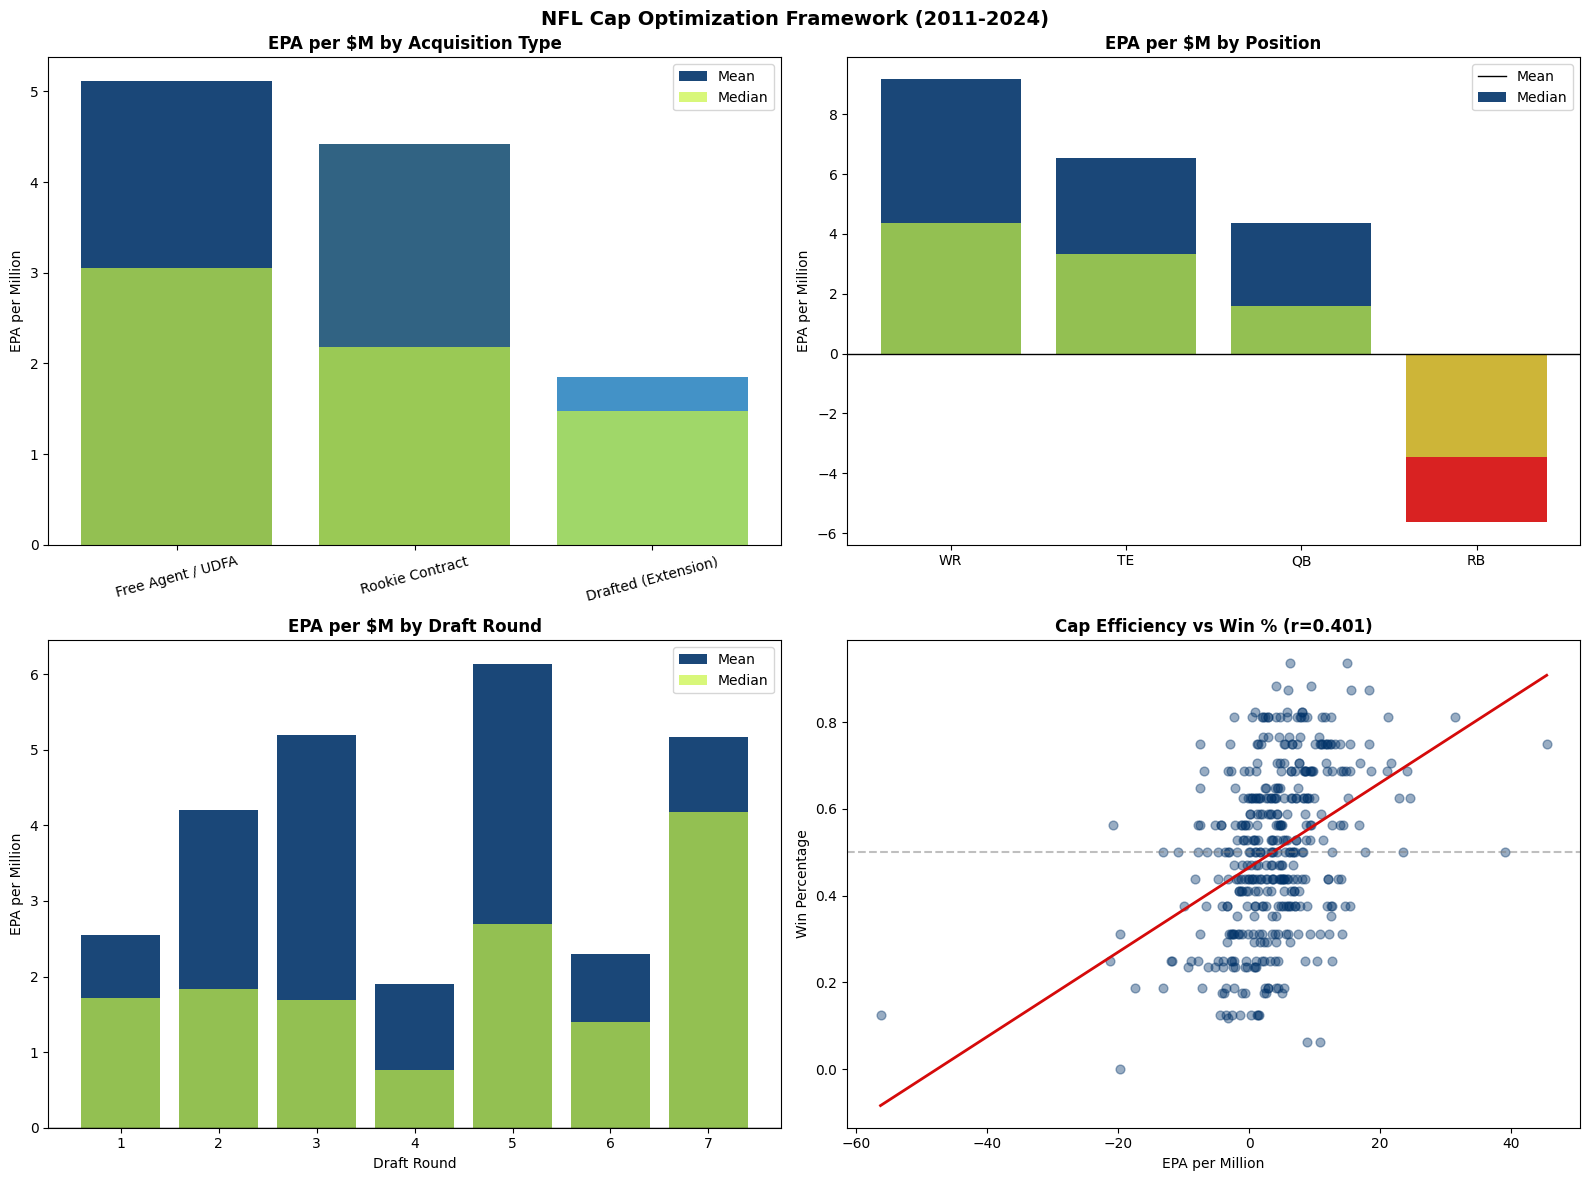

In [11]:
# Summary visualization - the key principles
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. EPA per million by acquisition type
acq_data = cap_eff.groupby('acquisition_type')['epa_per_million'].agg(['mean', 'median']).reset_index()
acq_data = acq_data.sort_values('mean', ascending=False)
colors = ['#013369', '#1a5276', '#2e86c1']
axes[0][0].bar(acq_data['acquisition_type'], acq_data['mean'], color=colors, alpha=0.9)
axes[0][0].bar(acq_data['acquisition_type'], acq_data['median'], color='#c8f542', alpha=0.7)
axes[0][0].set_title('EPA per $M by Acquisition Type', fontweight='bold')
axes[0][0].set_ylabel('EPA per Million')
axes[0][0].tick_params(axis='x', rotation=15)
axes[0][0].legend(['Mean', 'Median'])

# 2. EPA per million by position
pos_data = cap_eff[cap_eff['position_group'].isin(['QB','WR','TE','RB'])].groupby(
    'position_group')['epa_per_million'].agg(['mean','median']).reset_index()
pos_data = pos_data.sort_values('mean', ascending=False)
pos_colors = ['#013369' if x > 0 else '#D50A0A' for x in pos_data['mean']]
axes[0][1].bar(pos_data['position_group'], pos_data['mean'], color=pos_colors, alpha=0.9)
axes[0][1].bar(pos_data['position_group'], pos_data['median'], color='#c8f542', alpha=0.7)
axes[0][1].axhline(y=0, color='black', linewidth=1)
axes[0][1].set_title('EPA per $M by Position', fontweight='bold')
axes[0][1].set_ylabel('EPA per Million')
axes[0][1].legend(['Mean', 'Median'])

# 3. Draft round efficiency
drafted = cap_eff[cap_eff['draft_round'].notna()].copy()
drafted['draft_round'] = drafted['draft_round'].astype(int)
drafted = drafted[drafted['draft_round'] <= 7]
round_data = drafted.groupby('draft_round')['epa_per_million'].agg(['mean','median']).reset_index()
axes[1][0].bar(round_data['draft_round'], round_data['mean'], color='#013369', alpha=0.9, label='Mean')
axes[1][0].bar(round_data['draft_round'], round_data['median'], color='#c8f542', alpha=0.7, label='Median')
axes[1][0].axhline(y=0, color='black', linewidth=1)
axes[1][0].set_title('EPA per $M by Draft Round', fontweight='bold')
axes[1][0].set_xlabel('Draft Round')
axes[1][0].set_ylabel('EPA per Million')
axes[1][0].set_xticks(range(1, 8))
axes[1][0].legend()

# 4. EPA per million vs win pct
axes[1][1].scatter(team_season['avg_epa_per_m'], team_season['win_pct'],
                   alpha=0.4, color='#013369', s=40)
z = np.polyfit(team_season['avg_epa_per_m'].dropna(),
               team_season.loc[team_season['avg_epa_per_m'].notna(), 'win_pct'], 1)
p = np.poly1d(z)
x_line = np.linspace(team_season['avg_epa_per_m'].min(),
                     team_season['avg_epa_per_m'].max(), 100)
axes[1][1].plot(x_line, p(x_line), color='#D50A0A', linewidth=2)
axes[1][1].axhline(y=0.5, color='gray', linestyle='--', alpha=0.5)
axes[1][1].set_title('Cap Efficiency vs Win % (r=0.401)', fontweight='bold')
axes[1][1].set_xlabel('EPA per Million')
axes[1][1].set_ylabel('Win Percentage')

plt.suptitle('NFL Cap Optimization Framework (2011-2024)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(figures_path, "cap_optimization_framework.png"), dpi=150, bbox_inches='tight')
plt.show()

![Cap Optimization Framework](../outputs/figures/cap_optimization_framework.png)

The four-panel framework chart consolidates every major finding into a single visualization:

**Top left — Acquisition type:** Free agents and UDFAs lead in median efficiency, rookie contracts are close behind, extensions are significantly less efficient. The gap between rookie contracts and extensions is the most actionable finding for roster construction.

**Top right — Position:** WR and TE generate positive EPA per dollar, QB is moderate, RB is deeply negative. The red bar on RB is the clearest visual argument against paying running backs in the modern NFL.

**Bottom left — Draft round:** The non-linear pattern is striking — Round 1 is least efficient, Rounds 3 and 5-7 peak. Round 4 is a dead zone. Teams should target Rounds 2-3 and 5-7 for maximum value.

**Bottom right — Efficiency vs wins:** The positive trend line with r=0.401 confirms that cap efficiency is a meaningful predictor of team success. The scatter confirms it's not deterministic — great defense and coaching matter too.

---

### Summary
This notebook completes the cap optimization framework with the clearest actionable findings in the project:

1. **It's not where you spend, it's how efficiently you spend** — positional allocation has near-zero correlation with winning; EPA per million has 0.401 correlation
2. **Maximize rookie contract value** — players on rookie deals generate 12x more EPA per dollar than extensions
3. **Never pay running backs** — negative EPA per million at every price point, every year, without exception
4. **Target Rounds 2-3 and 5-7 in the draft** — Round 1 is the least efficient round due to cost; late rounds offer extraordinary upside at minimal cost
5. **Avoid extensions at market rate** — the market consistently overpays for past performance; extensions are the least efficient acquisition method
6. **Free agents outperform extensions** — proven veterans on market contracts provide more reliable cap value than re-signed players